In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style="whitegrid")

In [3]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/processed/clean_nav_history.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
performance = pd.read_csv("../data/processed/clean_scheme_performance.csv")
transactions = pd.read_csv("../data/processed/clean_investor_transactions.csv")
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print("AUM")
print(aum.columns.tolist())

print("\nSIP")
print(sip.columns.tolist())

print("\nCategory")
print(category.columns.tolist())

print("\nFolio")
print(folio.columns.tolist())

print("\nHoldings")
print(holdings.columns.tolist())

# NAV Trend Analysis (2022–2026)

This visualization shows the NAV movement of all mutual fund schemes from 2022 to 2026.

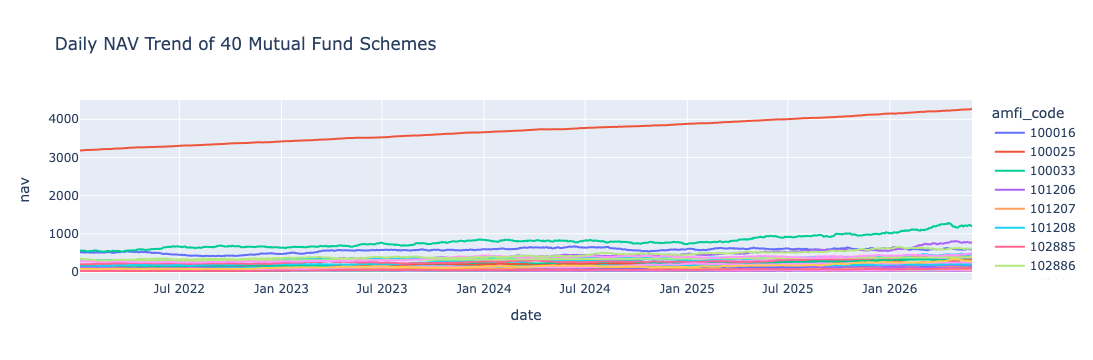

In [6]:
nav["date"] = pd.to_datetime(nav["date"])

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend of 40 Mutual Fund Schemes"
)

fig.show()

In [7]:
fig.write_html("../reports/nav_trend.html")

Insight 1:
    
SBI Mutual Fund maintained industry leadership by AUM and approached ₹12.5 lakh crore, significantly ahead of peers.

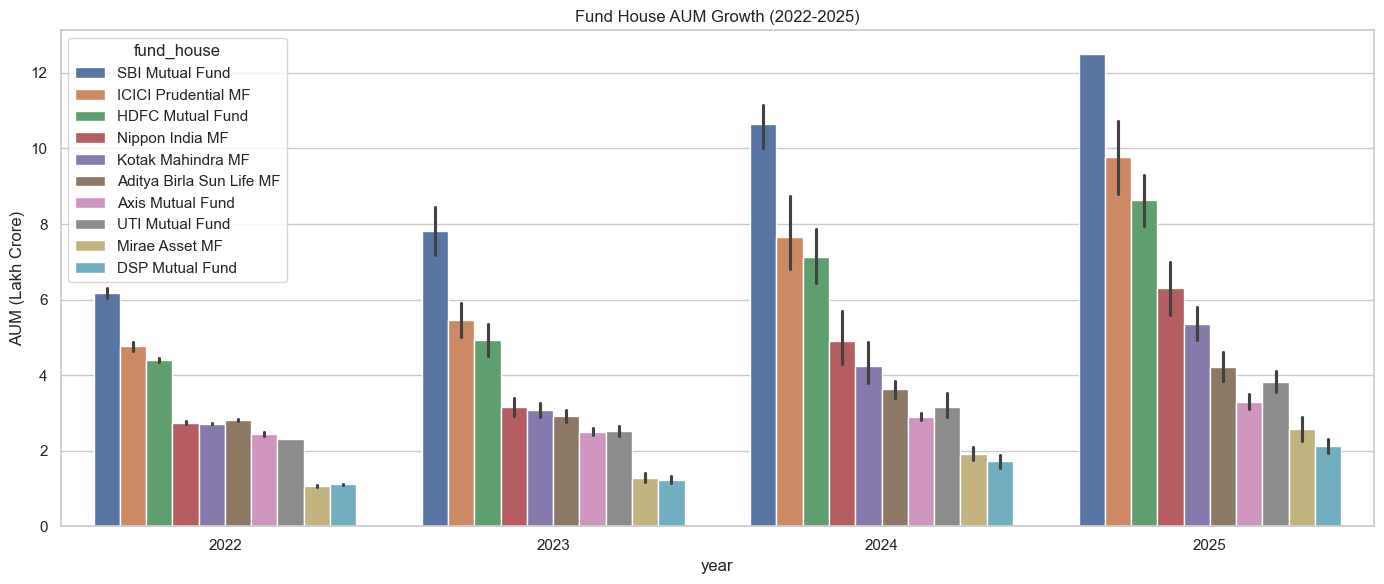

In [8]:
aum["date"] = pd.to_datetime(aum["date"])

aum["year"] = aum["date"].dt.year

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("Fund House AUM Growth (2022-2025)")
plt.ylabel("AUM (Lakh Crore)")
plt.tight_layout()

plt.show()

Insight 2:
    
Monthly SIP inflows increased consistently and crossed ₹31,000 crore by the end of 2025.

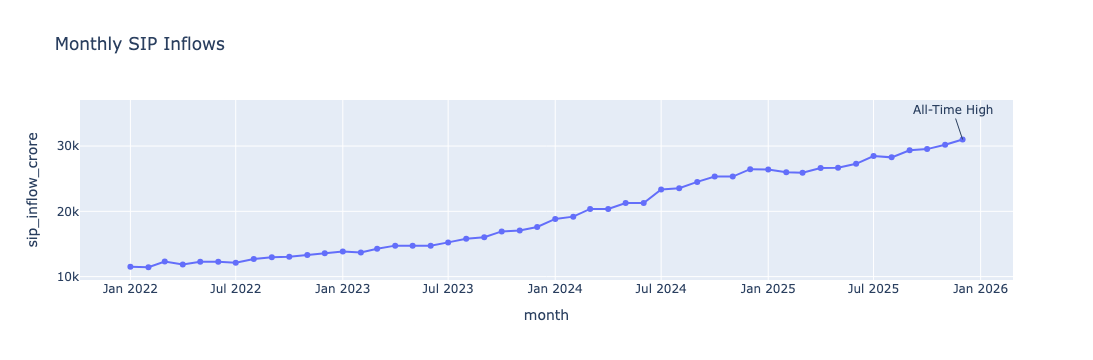

In [9]:
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows"
)

fig.add_annotation(
    x=sip.loc[
        sip["sip_inflow_crore"].idxmax(),
        "month"
    ],
    y=sip["sip_inflow_crore"].max(),
    text="All-Time High",
    showarrow=True
)

fig.show()

Insight 3:
    
Large-cap and flexi-cap categories attracted the strongest inflows during the study period.

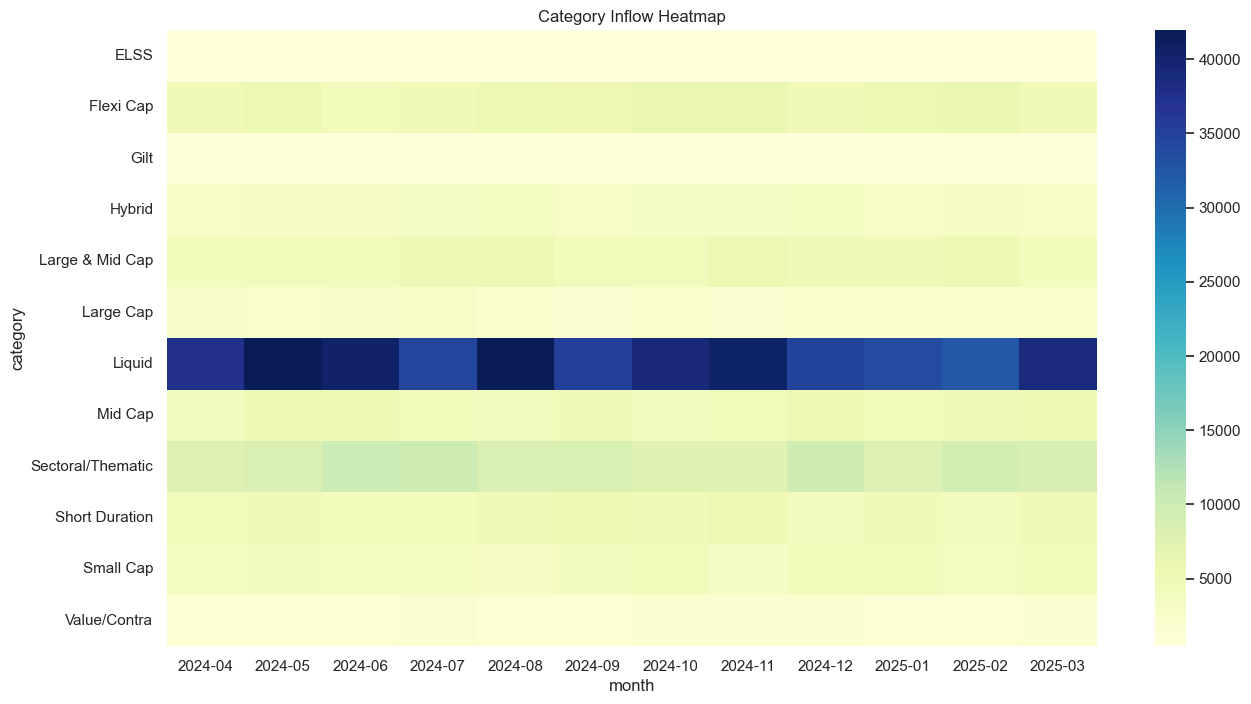

In [10]:
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(15,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")

plt.show()

Insight 4:
    
The majority of investors belong to the working-age population, indicating strong long-term wealth creation participation.

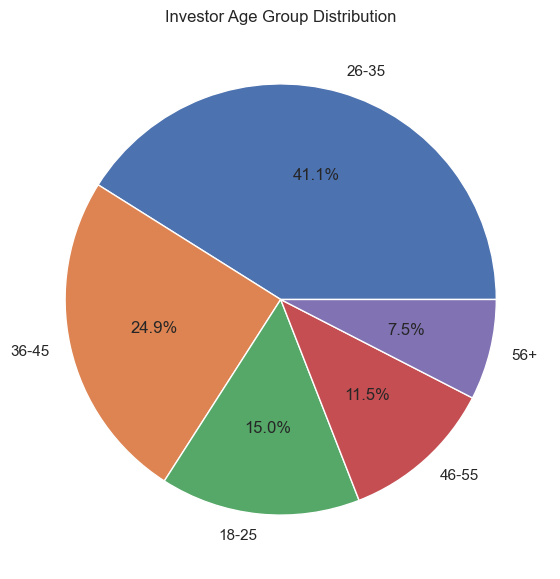

In [11]:
transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7,7)
)

plt.title("Investor Age Group Distribution")
plt.ylabel("")

plt.show()

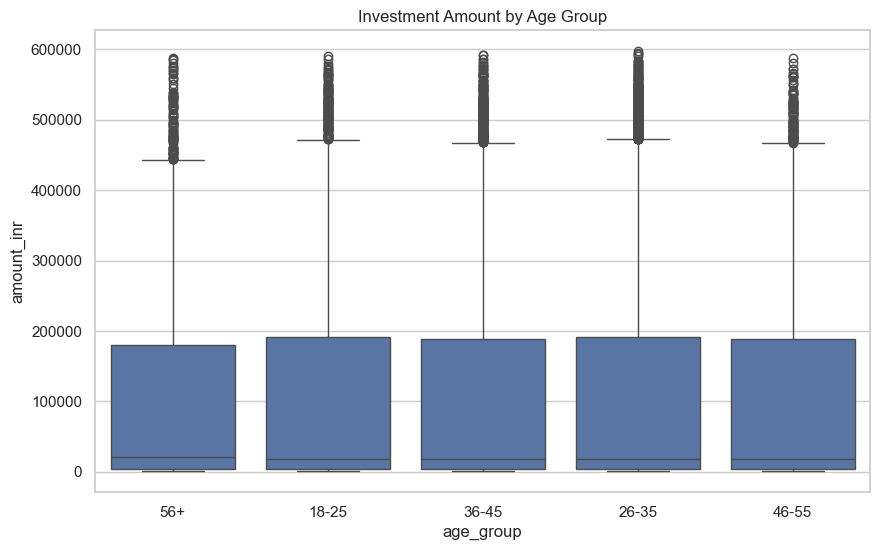

In [12]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")

plt.show()

Insight 5:
    
Male investors account for a larger share of transactions, although female participation remains significant.

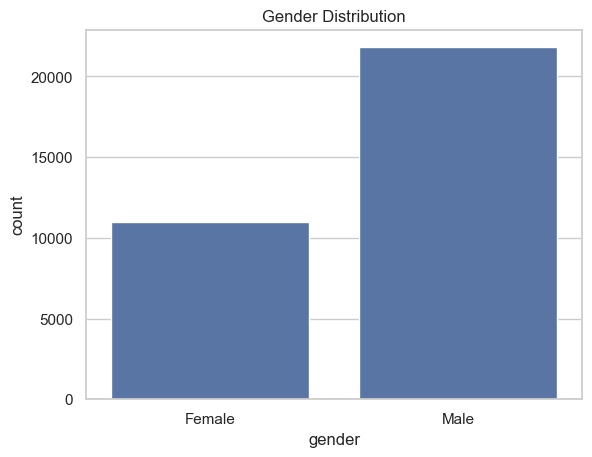

In [13]:
sns.countplot(
    data=transactions,
    x="gender"
)

plt.title("Gender Distribution")

plt.show()

Insight 6:
    
A small number of states contribute a disproportionately large share of total investment activity.

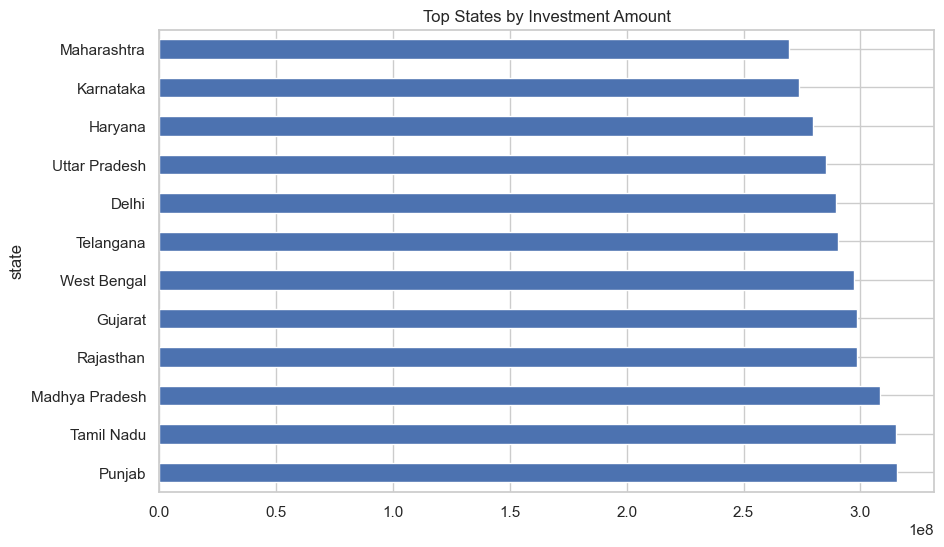

In [14]:
state_amount = (
    transactions.groupby("state")
    ["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10,6))

state_amount.plot(kind="barh")

plt.title("Top States by Investment Amount")

plt.show()

Insight 7:
    
T30 cities continue to dominate mutual fund investments, but B30 participation is steadily growing.

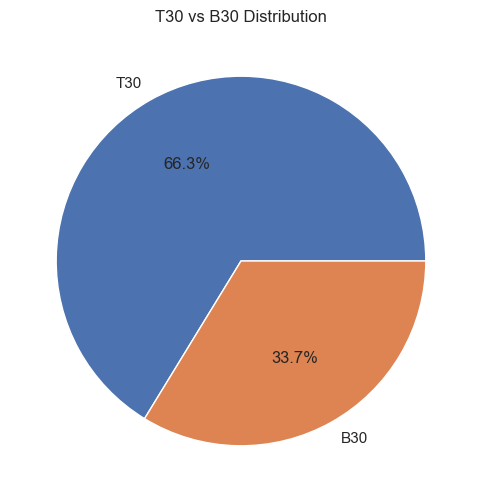

In [15]:
transactions["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("T30 vs B30 Distribution")
plt.ylabel("")

plt.show()

Insight 8:
    
Industry folio counts nearly doubled between 2022 and 2025, indicating rapid investor adoption.

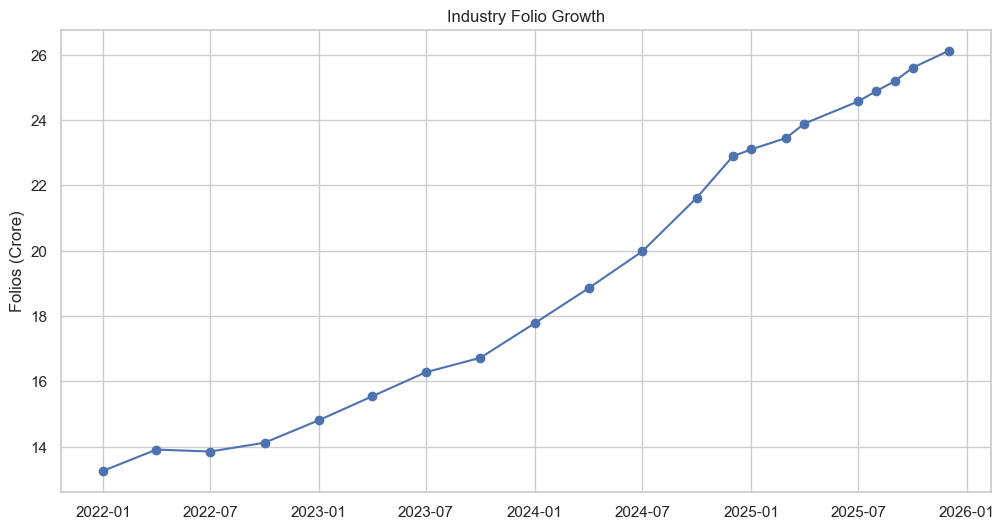

In [16]:
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Industry Folio Growth")
plt.ylabel("Folios (Crore)")

plt.show()

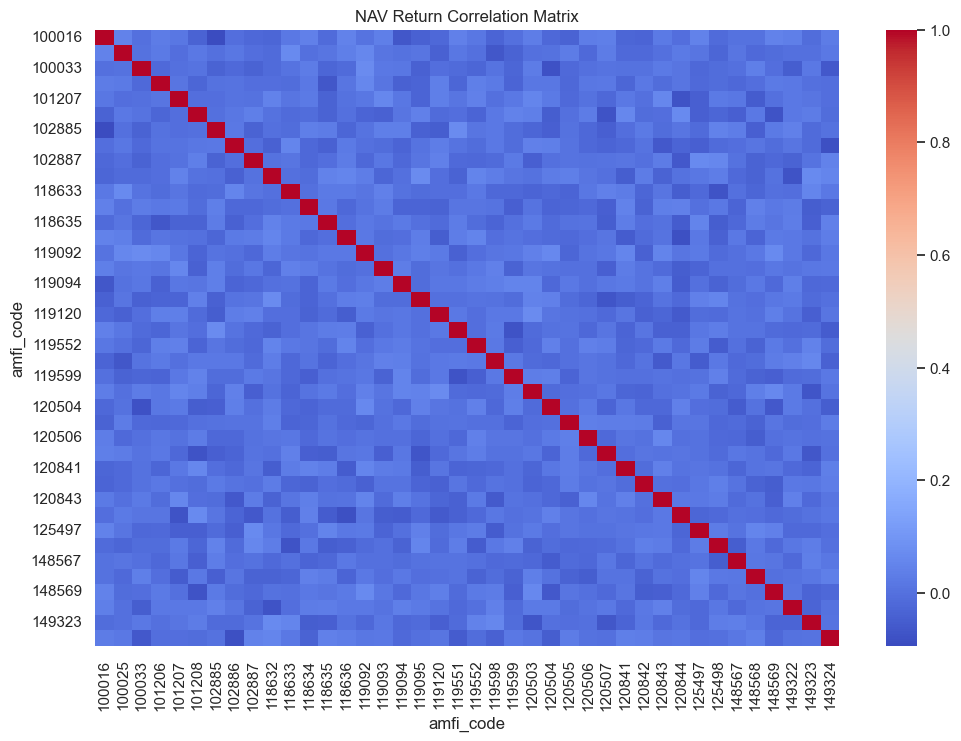

In [21]:
nav_pivot = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = nav_pivot.pct_change()

corr = returns.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("NAV Return Correlation Matrix")
plt.show()

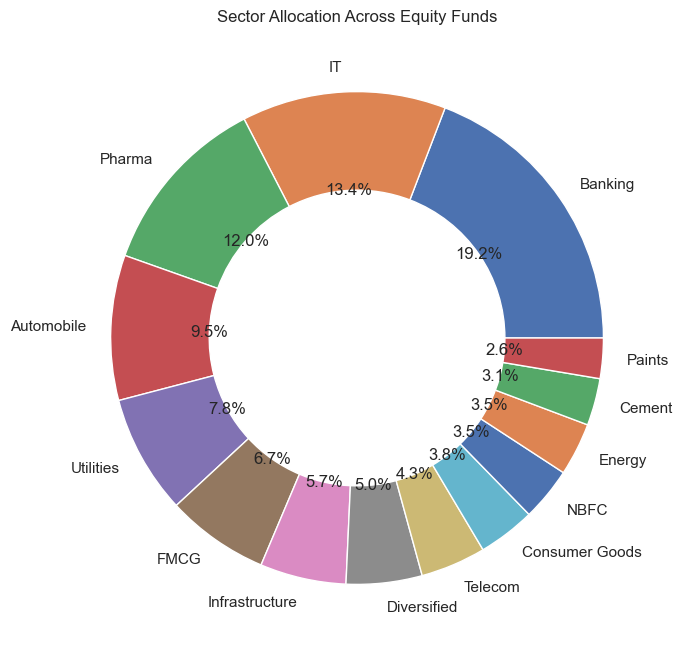

In [22]:
sector = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index,
    wedgeprops={"width":0.4},
    autopct="%1.1f%%"
)

plt.title("Sector Allocation Across Equity Funds")
plt.show()

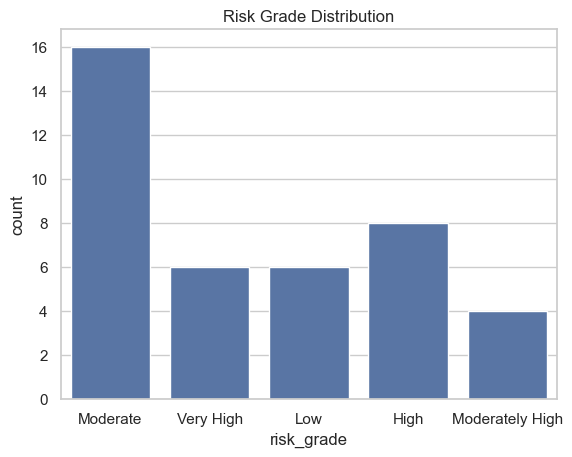

In [23]:
sns.countplot(
    data=performance,
    x="risk_grade"
)

plt.title("Risk Grade Distribution")
plt.show()

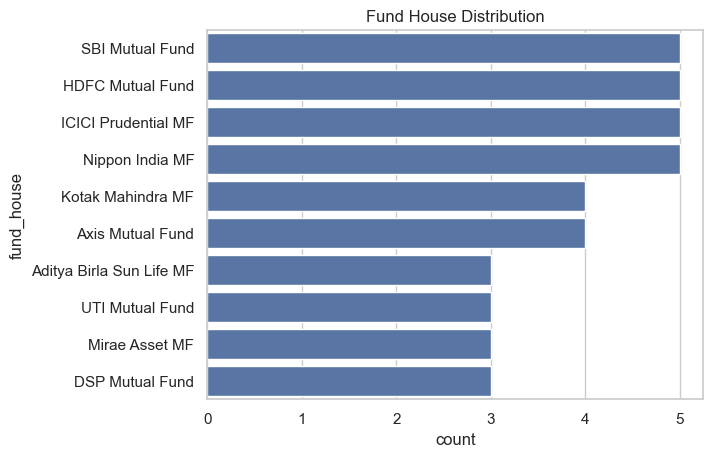

In [24]:
sns.countplot(
    data=fund_master,
    y="fund_house"
)

plt.title("Fund House Distribution")
plt.show()

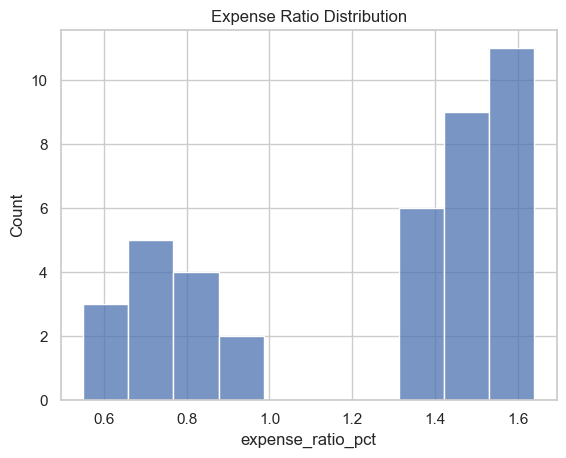

In [25]:
sns.histplot(
    performance["expense_ratio_pct"],
    bins=10
)

plt.title("Expense Ratio Distribution")
plt.show()

In [27]:
import os
import matplotlib.pyplot as plt

# Create folder if it doesn't exist
os.makedirs("../reports/charts", exist_ok=True)

chart_names = [
    "nav_trend",
    "aum_growth",
    "sip_inflow_trend",
    "category_heatmap",
    "age_distribution",
    "age_boxplot",
    "gender_distribution",
    "state_distribution",
    "city_tier_distribution",
    "folio_growth",
    "correlation_matrix",
    "sector_allocation",
    "risk_grade_distribution",
    "fund_house_distribution",
    "expense_ratio_distribution"
]

for i, fig_num in enumerate(plt.get_fignums()):
    fig = plt.figure(fig_num)

    if i < len(chart_names):
        filename = f"../reports/charts/{chart_names[i]}.png"
    else:
        filename = f"../reports/charts/chart_{i+1}.png"

    fig.savefig(filename, bbox_inches="tight")

print("All charts exported successfully!")
print(f"Total charts exported: {len(plt.get_fignums())}")

All charts exported successfully!
Total charts exported: 0


# Key EDA Findings

1. SBI Mutual Fund maintained industry leadership by AUM.
2. SIP inflows reached record levels by 2025.
3. Large-cap and flexi-cap funds attracted strong inflows.
4. The 26–35 age group accounted for 41.07% of investors.
5. Investors aged 36–45 represented nearly 25% of participation.
6. More than 66% of investors belonged to the 26–45 age bracket.
7. T30 cities contributed 66.3% of total participation.
8. Industry folio counts nearly doubled between 2022 and 2025.
9. Male investors represented 66.5% of total investors.
10. Female investors accounted for 33.5% of participation.